In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

base = '/content/drive/MyDrive/Attrition_Project'

folders = ['data/raw', 'data/processed', 'notebooks', 'models', 'outputs/plots', 'outputs/reports']

for folder in folders:
    os.makedirs(os.path.join(base, folder), exist_ok=True)

print("Project folders created successfully!")

Project folders created successfully!


In [3]:
import urllib.request

url = "https://raw.githubusercontent.com/IBM/employee-attrition-aif360/master/data/emp_attrition.csv"
save_path = '/content/drive/MyDrive/Attrition_Project/data/raw/hr_attrition.csv'

urllib.request.urlretrieve(url, save_path)
print("Dataset downloaded!")

Dataset downloaded!


In [4]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Attrition_Project/data/raw/hr_attrition.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (1470, 35)

First 5 rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
# Check column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [6]:
# Check for missing values
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [7]:
# Check attrition distribution
df['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


**Exploratory Data Analysis (EDA)**

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)

print("Libraries ready!")

Libraries ready!


Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate: 16.1%


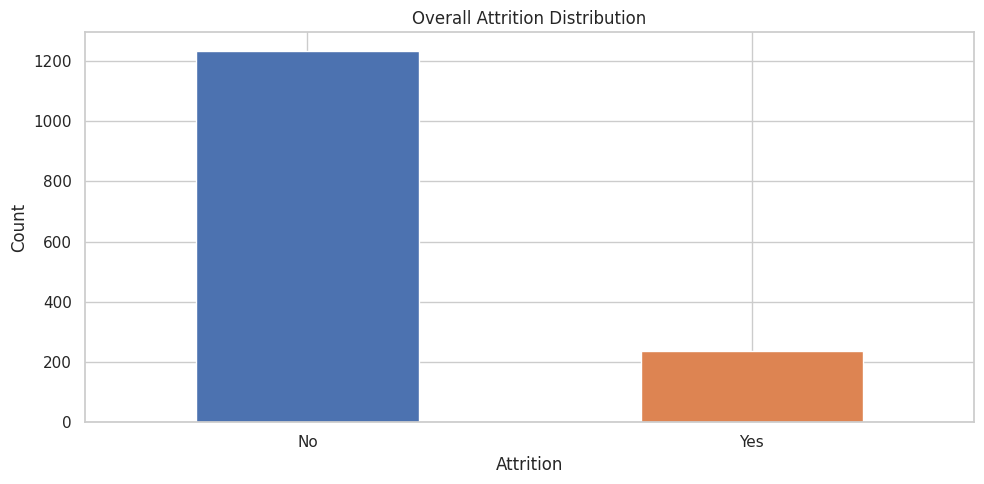

In [9]:
attrition_counts = df['Attrition'].value_counts()
attrition_pct = df['Attrition'].value_counts(normalize=True) * 100

print(attrition_counts)
print("\nAttrition Rate: {:.1f}%".format(attrition_pct['Yes']))

# Plot
attrition_counts.plot(kind='bar', color=['#4C72B0', '#DD8452'], edgecolor='white')
plt.title('Overall Attrition Distribution')
plt.xlabel('Attrition')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Attrition_Project/outputs/plots/attrition_distribution.png', dpi=150)
plt.show()

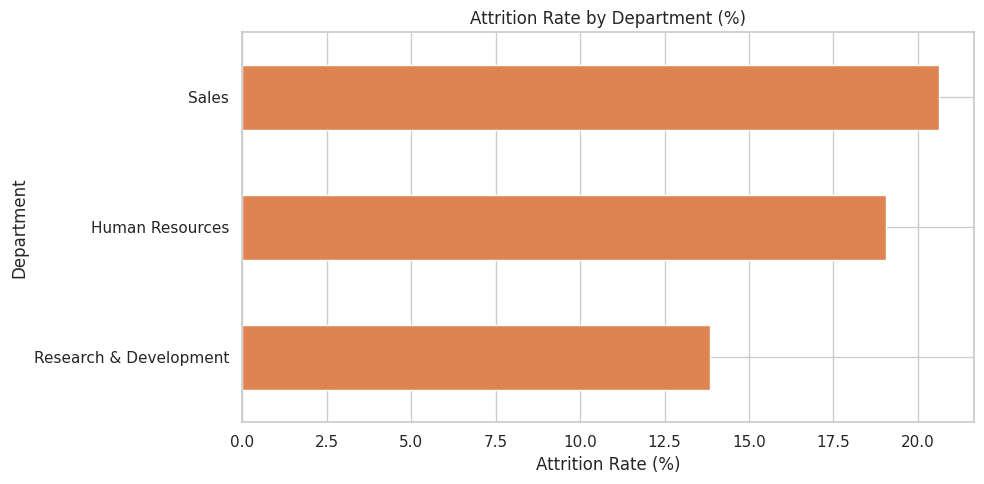

In [10]:
dept_attrition = df.groupby('Department')['Attrition'].value_counts(normalize=True).unstack() * 100

dept_attrition['Yes'].sort_values().plot(kind='barh', color='#DD8452', edgecolor='white')
plt.title('Attrition Rate by Department (%)')
plt.xlabel('Attrition Rate (%)')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Attrition_Project/outputs/plots/attrition_by_dept.png', dpi=150)
plt.show()

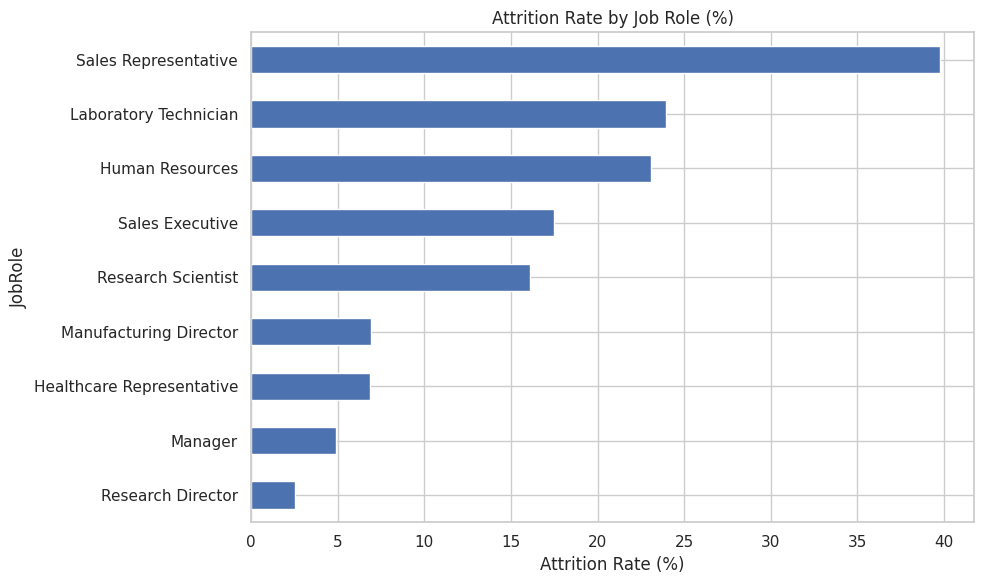

In [11]:
role_attrition = df.groupby('JobRole')['Attrition'].value_counts(normalize=True).unstack() * 100

role_attrition['Yes'].sort_values().plot(kind='barh', color='#4C72B0', edgecolor='white', figsize=(10, 6))
plt.title('Attrition Rate by Job Role (%)')
plt.xlabel('Attrition Rate (%)')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Attrition_Project/outputs/plots/attrition_by_role.png', dpi=150)
plt.show()

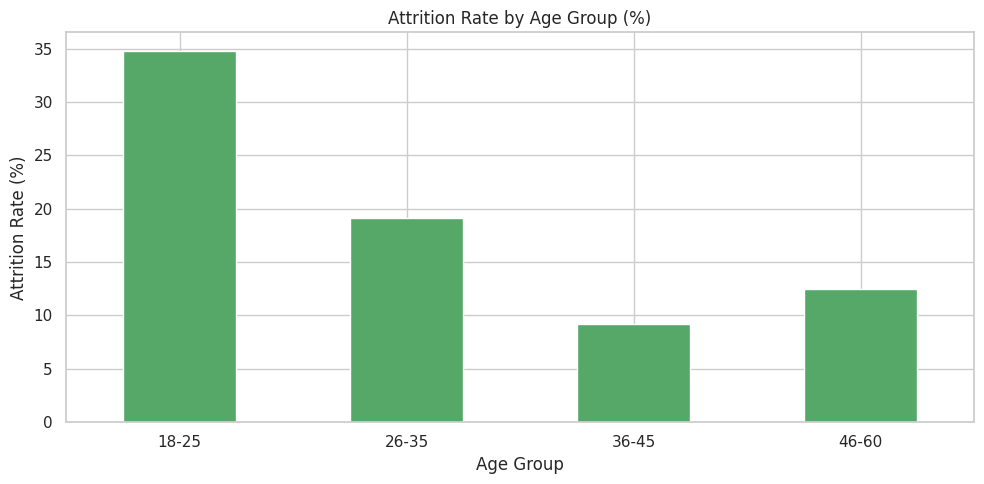

In [12]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[18, 25, 35, 45, 60], labels=['18-25', '26-35', '36-45', '46-60'])

age_attrition = df.groupby('AgeGroup', observed=True)['Attrition'].value_counts(normalize=True).unstack() * 100

age_attrition['Yes'].plot(kind='bar', color='#55A868', edgecolor='white')
plt.title('Attrition Rate by Age Group (%)')
plt.xlabel('Age Group')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Attrition_Project/outputs/plots/attrition_by_age.png', dpi=150)
plt.show()

/tmp/ipykernel_1335/4196282646.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette={'No': '#4C72B0', 'Yes': '#DD8452'})


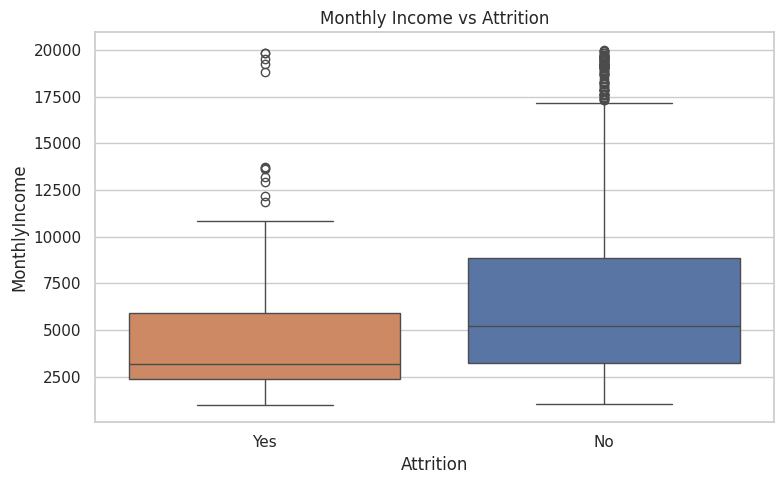

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette={'No': '#4C72B0', 'Yes': '#DD8452'})
plt.title('Monthly Income vs Attrition')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Attrition_Project/outputs/plots/income_vs_attrition.png', dpi=150)
plt.show()

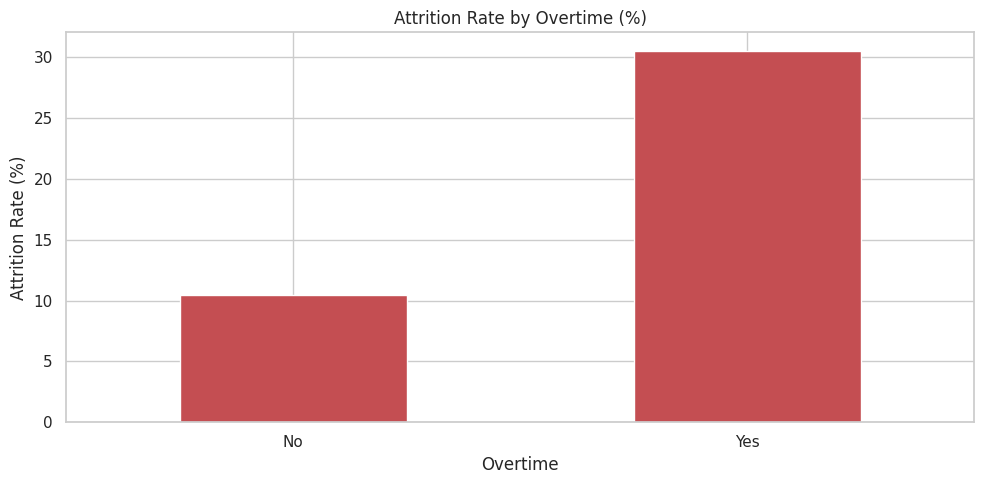

In [14]:
overtime = df.groupby('OverTime')['Attrition'].value_counts(normalize=True).unstack() * 100

overtime['Yes'].plot(kind='bar', color='#C44E52', edgecolor='white')
plt.title('Attrition Rate by Overtime (%)')
plt.xlabel('Overtime')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Attrition_Project/outputs/plots/overtime_vs_attrition.png', dpi=150)
plt.show()

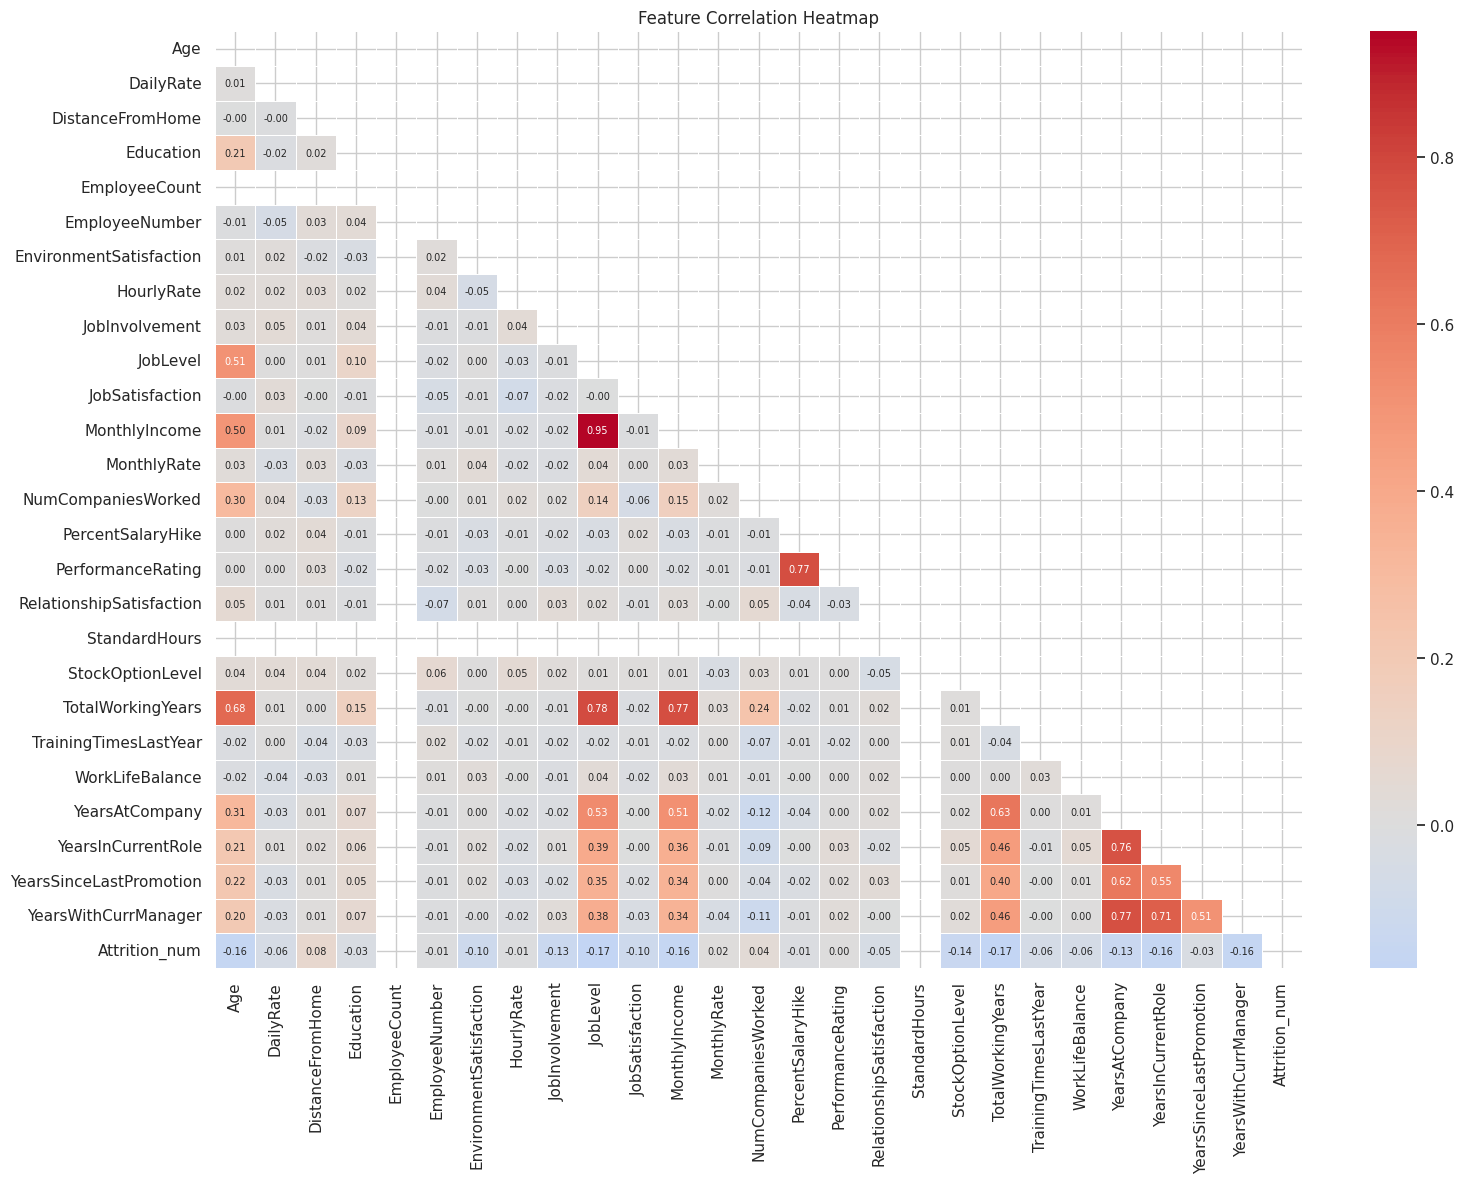

In [15]:
# Convert Attrition to numeric for correlation
df_corr = df.copy()
df_corr['Attrition_num'] = (df_corr['Attrition'] == 'Yes').astype(int)

# Select only numeric columns
numeric_cols = df_corr.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(16, 12))
corr_matrix = df_corr[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={"size": 7})
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Attrition_Project/outputs/plots/correlation_heatmap.png', dpi=150)
plt.show()

**EDA Key Findings:**
- Overall attrition rate: ~16% (imbalanced dataset)
- Highest attrition: Sales Representatives, younger employees (18-25)
- Strong predictors: OverTime, MonthlyIncome, Age, JobRole
- Employees doing overtime leave at ~3x the rate of those who don't
- Lower income strongly associated with attrition

**Data Preprocessing & Feature Engineering**

In [16]:
!pip install imbalanced-learn -q

In [17]:
cols_to_drop = [
    'EmployeeCount',    # same value for everyone
    'EmployeeNumber',   # just an ID
    'Over18',           # same value for everyone
    'StandardHours',    # same value for everyone
    'JobLevel',         # 0.95 corr with MonthlyIncome — redundant
]

df_clean = df.drop(columns=cols_to_drop)
print("Remaining columns:", df_clean.shape[1])

Remaining columns: 31


In [18]:
df_clean = df_clean.drop(columns=['AgeGroup'])
print("Shape after dropping AgeGroup:", df_clean.shape)

Shape after dropping AgeGroup: (1470, 30)


In [19]:
df_clean['Attrition'] = (df_clean['Attrition'] == 'Yes').astype(int)
print(df_clean['Attrition'].value_counts())

Attrition
0    1233
1     237
Name: count, dtype: int64


In [20]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = df_clean.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", categorical_cols)

le = LabelEncoder()
for col in categorical_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

print("\nAll columns are now numeric.")
df_clean.head()

Categorical columns to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

All columns are now numeric.


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,2,0,...,3,1,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,3,1,...,4,4,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,4,1,...,3,2,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,4,0,...,3,3,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,1,...,3,4,1,6,3,3,2,2,2,2


In [21]:
X = df_clean.drop(columns=['Attrition'])
y = df_clean['Attrition']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Attrition rate:", y.mean().round(3))

Features shape: (1470, 29)
Target shape: (1470,)
Attrition rate: 0.161


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("Train attrition rate:", y_train.mean().round(3))
print("Test attrition rate:", y_test.mean().round(3))

Training set: (1176, 29)
Test set: (294, 29)
Train attrition rate: 0.162
Test attrition rate: 0.16


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done. Train shape:", X_train_scaled.shape)

Scaling done. Train shape: (1176, 29)


In [24]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_resampled.value_counts().to_dict())

Before SMOTE: {0: 986, 1: 190}
After SMOTE: {0: 986, 1: 986}


In [25]:
import numpy as np

np.save('/content/drive/MyDrive/Attrition_Project/data/processed/X_train.npy', X_train_resampled)
np.save('/content/drive/MyDrive/Attrition_Project/data/processed/X_test.npy', X_test_scaled)
np.save('/content/drive/MyDrive/Attrition_Project/data/processed/y_train.npy', y_train_resampled)
np.save('/content/drive/MyDrive/Attrition_Project/data/processed/y_test.npy', y_test)

import joblib
joblib.dump(scaler, '/content/drive/MyDrive/Attrition_Project/models/scaler.pkl')

print("All processed data saved!")

All processed data saved!


**Phase 4 — ML Model Building**

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import numpy as np
import joblib

print("All imports successful!")

All imports successful!


In [27]:
X_train = np.load('/content/drive/MyDrive/Attrition_Project/data/processed/X_train.npy')
X_test  = np.load('/content/drive/MyDrive/Attrition_Project/data/processed/X_test.npy')
y_train = np.load('/content/drive/MyDrive/Attrition_Project/data/processed/y_train.npy')
y_test  = np.load('/content/drive/MyDrive/Attrition_Project/data/processed/y_test.npy')

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (1972, 29) Test: (294, 29)


**Model 1: Logistic Regression (baseline)**

In [28]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr).round(4))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.95      0.77      0.85       247
           1       0.39      0.79      0.52        47

    accuracy                           0.77       294
   macro avg       0.67      0.78      0.69       294
weighted avg       0.86      0.77      0.80       294

ROC-AUC: 0.8022


**Model 2: Random Forest**

In [29]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf).round(4))

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.87      0.96      0.92       247
           1       0.57      0.26      0.35        47

    accuracy                           0.85       294
   macro avg       0.72      0.61      0.63       294
weighted avg       0.82      0.85      0.83       294

ROC-AUC: 0.7939


**Model 3: XGBoost**

In [30]:
xgb = XGBClassifier(n_estimators=100, random_state=42,
                    use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb).round(4))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:14:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== XGBoost ===
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       247
           1       0.69      0.38      0.49        47

    accuracy                           0.87       294
   macro avg       0.79      0.68      0.71       294
weighted avg       0.86      0.87      0.86       294

ROC-AUC: 0.7956


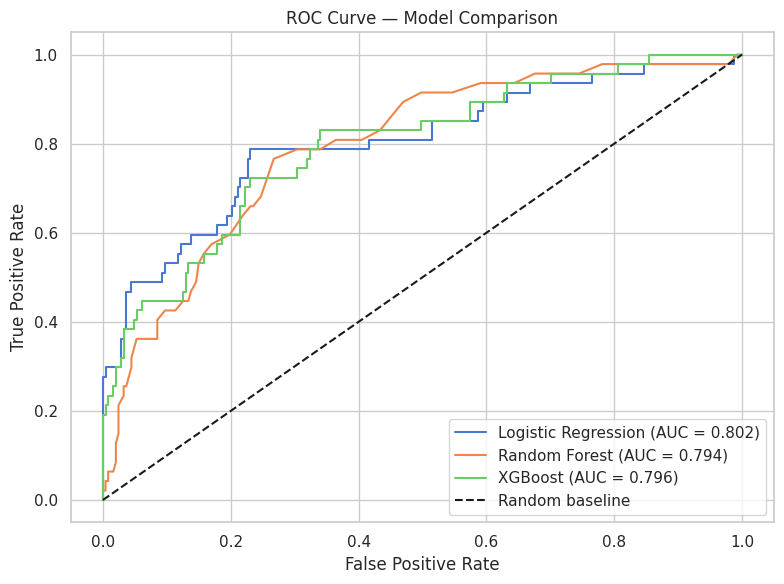

In [31]:
models = {
    'Logistic Regression': (y_prob_lr, y_pred_lr),
    'Random Forest':       (y_prob_rf, y_pred_rf),
    'XGBoost':             (y_prob_xgb, y_pred_xgb)
}

# ROC Curve comparison
plt.figure(figsize=(8, 6))
for name, (y_prob, _) in models.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob).round(3)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc})')

plt.plot([0,1],[0,1],'k--', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Model Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Attrition_Project/outputs/plots/roc_comparison.png', dpi=150)
plt.show()

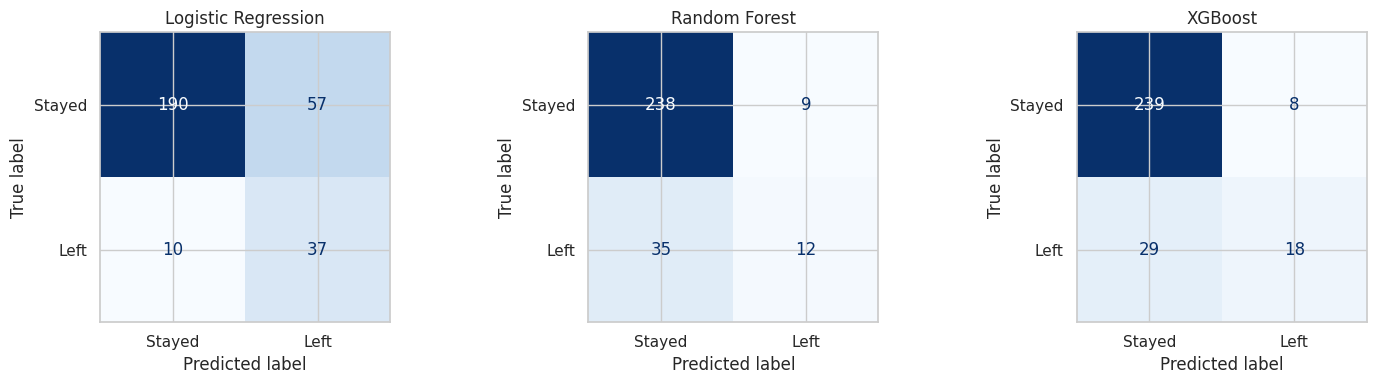

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, (_, y_pred)) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Stayed', 'Left'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Attrition_Project/outputs/plots/confusion_matrices.png', dpi=150)
plt.show()

In [33]:
for name, model in [('Logistic Regression', lr),
                    ('Random Forest', rf),
                    ('XGBoost', xgb)]:
    scores = cross_val_score(model, X_train, y_train,
                             cv=5, scoring='roc_auc')
    print(f"{name}: Mean AUC = {scores.mean():.4f} ± {scores.std():.4f}")

Logistic Regression: Mean AUC = 0.8592 ± 0.0206
Random Forest: Mean AUC = 0.9866 ± 0.0236


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:15:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:15:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:15:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:15:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

XGBoost: Mean AUC = 0.9810 ± 0.0373


In [34]:
# Save all 3 — we'll pick the winner after seeing results
joblib.dump(lr,  '/content/drive/MyDrive/Attrition_Project/models/logistic_regression.pkl')
joblib.dump(rf,  '/content/drive/MyDrive/Attrition_Project/models/random_forest.pkl')
joblib.dump(xgb, '/content/drive/MyDrive/Attrition_Project/models/xgboost.pkl')

print("All models saved!")

All models saved!


**Phase 5 — Model Explainability (SHAP)**

In [35]:
!pip install shap -q

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

print("SHAP ready!")

SHAP ready!


In [36]:
import numpy as np

X_train = np.load('/content/drive/MyDrive/Attrition_Project/data/processed/X_train.npy')
X_test  = np.load('/content/drive/MyDrive/Attrition_Project/data/processed/X_test.npy')
y_test  = np.load('/content/drive/MyDrive/Attrition_Project/data/processed/y_test.npy')

lr  = joblib.load('/content/drive/MyDrive/Attrition_Project/models/logistic_regression.pkl')
xgb = joblib.load('/content/drive/MyDrive/Attrition_Project/models/xgboost.pkl')

# Feature names (same order as your df_clean after dropping columns)
feature_names = [col for col in df_clean.drop(columns=['Attrition']).columns]

print("Feature count:", len(feature_names))

Feature count: 29


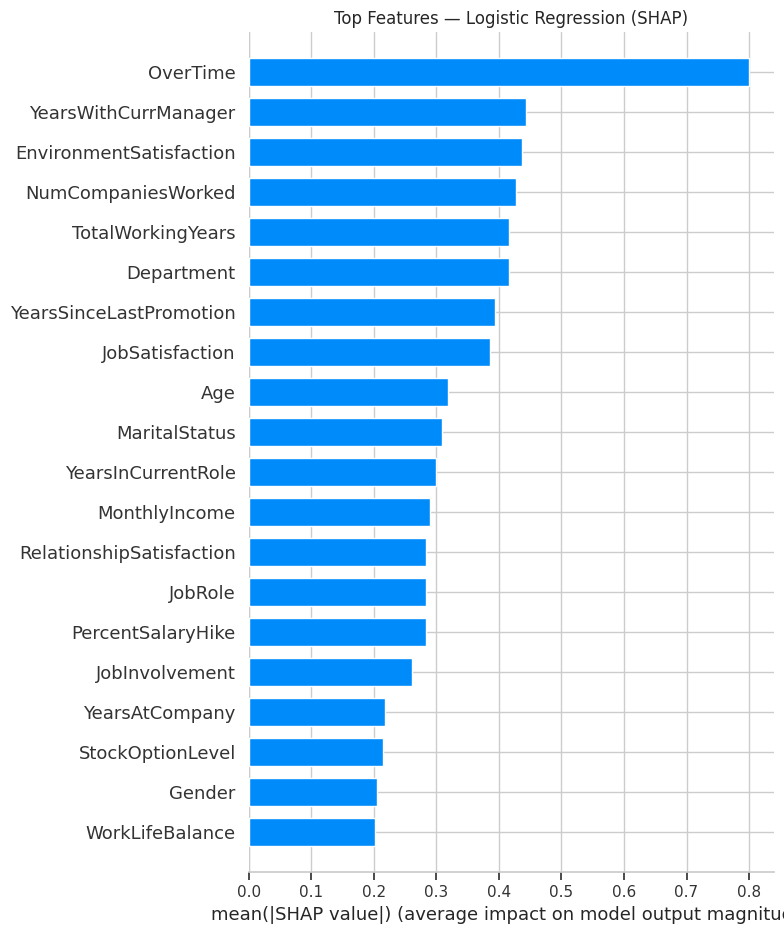

In [37]:
# Linear explainer is correct for Logistic Regression
explainer_lr = shap.LinearExplainer(lr, X_train)
shap_values_lr = explainer_lr.shap_values(X_test)

# Summary plot — shows which features matter most overall
shap.summary_plot(shap_values_lr, X_test,
                  feature_names=feature_names,
                  plot_type="bar",
                  show=False)
plt.title("Top Features — Logistic Regression (SHAP)")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Attrition_Project/outputs/plots/shap_lr_bar.png', dpi=150)
plt.show()

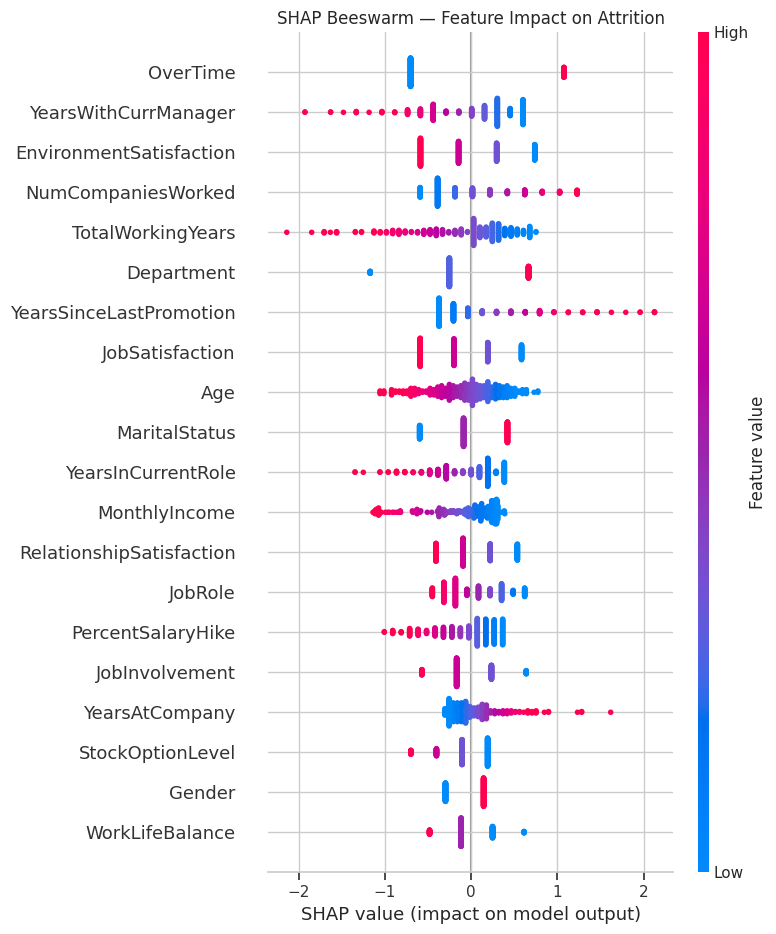

In [38]:
shap.summary_plot(shap_values_lr, X_test,
                  feature_names=feature_names,
                  show=False)
plt.title("SHAP Beeswarm — Feature Impact on Attrition")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Attrition_Project/outputs/plots/shap_lr_beeswarm.png', dpi=150)
plt.show()

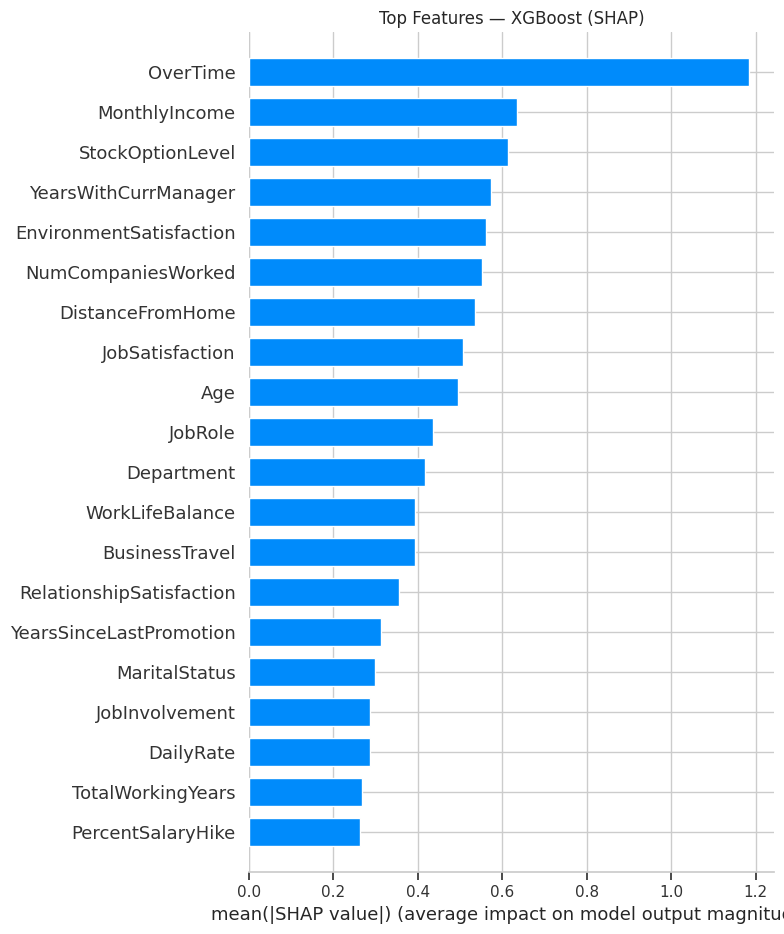

In [39]:
explainer_xgb = shap.TreeExplainer(xgb)
shap_values_xgb = explainer_xgb.shap_values(X_test)

shap.summary_plot(shap_values_xgb, X_test,
                  feature_names=feature_names,
                  plot_type="bar",
                  show=False)
plt.title("Top Features — XGBoost (SHAP)")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Attrition_Project/outputs/plots/shap_xgb_bar.png', dpi=150)
plt.show()

Explaining prediction for employee index 4
Actual outcome: Left
Model predicted probability of leaving: 83.13%


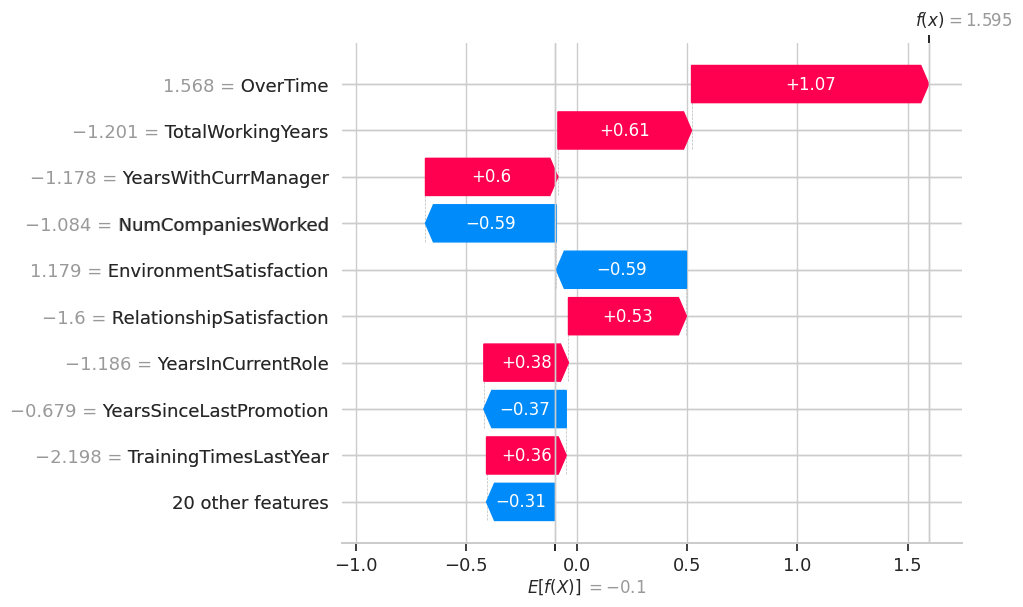

In [40]:
# Pick the first employee in test set who actually left
left_indices = np.where(y_test == 1)[0]
employee_idx = left_indices[0]

print(f"Explaining prediction for employee index {employee_idx}")
print(f"Actual outcome: {'Left' if y_test[employee_idx] == 1 else 'Stayed'}")
print(f"Model predicted probability of leaving: {lr.predict_proba(X_test)[employee_idx][1]:.2%}")

# Waterfall plot — shows exactly why this employee was flagged
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_lr[employee_idx],
        base_values=explainer_lr.expected_value,
        data=X_test[employee_idx],
        feature_names=feature_names
    )
)

In [41]:
# Create a clean dataframe of feature importances
shap_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean_SHAP': np.abs(shap_values_lr).mean(axis=0)
}).sort_values('Mean_SHAP', ascending=False).reset_index(drop=True)

print("Top 10 most important features:")
print(shap_df.head(10).to_string(index=False))

# Save it
shap_df.to_csv('/content/drive/MyDrive/Attrition_Project/outputs/reports/feature_importance.csv', index=False)

Top 10 most important features:
                Feature  Mean_SHAP
               OverTime   0.799961
   YearsWithCurrManager   0.442893
EnvironmentSatisfaction   0.436879
     NumCompaniesWorked   0.427767
      TotalWorkingYears   0.416591
             Department   0.415463
YearsSinceLastPromotion   0.393315
        JobSatisfaction   0.386298
                    Age   0.317954
          MaritalStatus   0.309167


**Phase 6 — NLP on Exit Survey Text**

In [42]:
!pip install vaderSentiment -q
!pip install gensim -q

print("NLP libraries ready!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 18.9 MB/s eta 0:00:00
NLP libraries ready!


In [43]:
import pandas as pd
import numpy as np
import random

random.seed(42)
np.random.seed(42)

# Comments mapped to real attrition drivers from our SHAP analysis
comment_templates = {
    'overtime': [
        "I was constantly working late with no work-life balance at all",
        "The overtime expectations were unreasonable and unsustainable",
        "I burned out from working weekends and late nights for months",
        "No respect for personal time, always expected to be available",
        "The workload was crushing and never got better despite raising it",
    ],
    'environment': [
        "The office environment was toxic and management ignored complaints",
        "I did not feel safe raising concerns with my manager",
        "The workplace culture was very negative and demotivating",
        "Poor team dynamics and constant internal conflicts",
        "The environment was not inclusive and I felt overlooked",
    ],
    'growth': [
        "There was no clear career path or growth opportunity here",
        "I waited two years for a promotion that never came",
        "Skills development was not supported or encouraged",
        "I felt stuck in the same role with no way forward",
        "Management never discussed my career goals with me",
    ],
    'compensation': [
        "My salary was not competitive compared to market rates",
        "Despite good performance reviews my pay never improved",
        "The compensation package was below industry standard",
        "I received a much better offer elsewhere with better benefits",
        "Pay increases were minimal and did not reflect my contributions",
    ],
    'manager': [
        "My manager provided very little support or feedback",
        "There was a complete lack of communication from leadership",
        "I had a poor relationship with my direct manager",
        "Management style was micromanaging and trust was absent",
        "My manager took credit for my work repeatedly",
    ]
}

# Get employees who left from original dataframe
left_employees = df_clean[df_clean['Attrition'] == 1].copy().reset_index(drop=True)

# Assign a primary reason and generate comment
reasons = list(comment_templates.keys())
left_employees['exit_reason'] = [random.choice(reasons) for _ in range(len(left_employees))]
left_employees['exit_comment'] = left_employees['exit_reason'].apply(
    lambda r: random.choice(comment_templates[r])
)

print(f"Generated {len(left_employees)} exit survey comments")
print("\nSample comments:")
print(left_employees[['exit_reason', 'exit_comment']].head(8).to_string(index=False))

Generated 237 exit survey comments

Sample comments:
exit_reason                                                      exit_comment
   overtime The workload was crushing and never got better despite raising it
   overtime     No respect for personal time, always expected to be available
     growth                I waited two years for a promotion that never came
environment                Poor team dynamics and constant internal conflicts
environment              I did not feel safe raising concerns with my manager
environment          The workplace culture was very negative and demotivating
   overtime     No respect for personal time, always expected to be available
    manager        There was a complete lack of communication from leadership


In [44]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    scores = analyzer.polarity_scores(text)
    compound = scores['compound']
    if compound <= -0.3:
        return 'Negative', compound
    elif compound >= 0.3:
        return 'Positive', compound
    else:
        return 'Neutral', compound

left_employees[['sentiment_label', 'sentiment_score']] = left_employees['exit_comment'].apply(
    lambda x: pd.Series(get_sentiment(x))
)

print("Sentiment distribution:")
print(left_employees['sentiment_label'].value_counts())
print("\nAverage sentiment score:", left_employees['sentiment_score'].mean().round(3))

Sentiment distribution:
sentiment_label
Negative    110
Neutral      77
Positive     50
Name: count, dtype: int64

Average sentiment score: -0.152


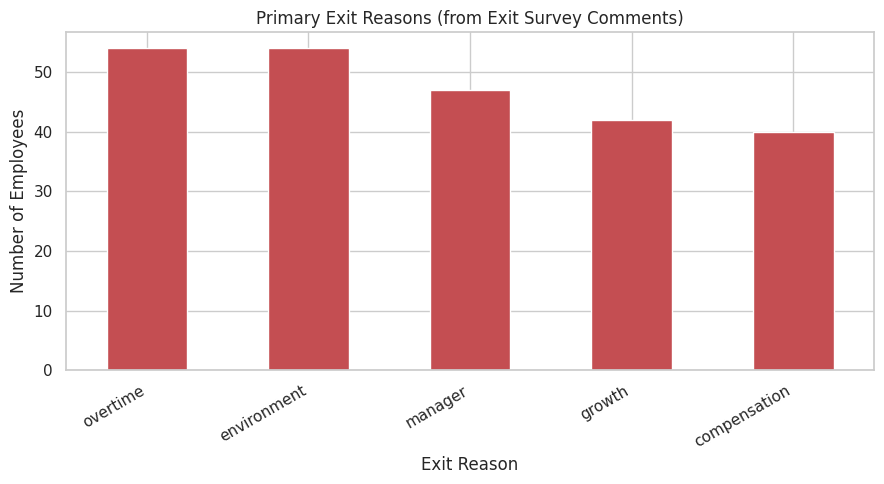

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Count by reason
reason_counts = left_employees['exit_reason'].value_counts()

plt.figure(figsize=(9, 5))
reason_counts.plot(kind='bar', color='#C44E52', edgecolor='white')
plt.title('Primary Exit Reasons (from Exit Survey Comments)')
plt.xlabel('Exit Reason')
plt.ylabel('Number of Employees')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Attrition_Project/outputs/plots/exit_reasons.png', dpi=150)
plt.show()

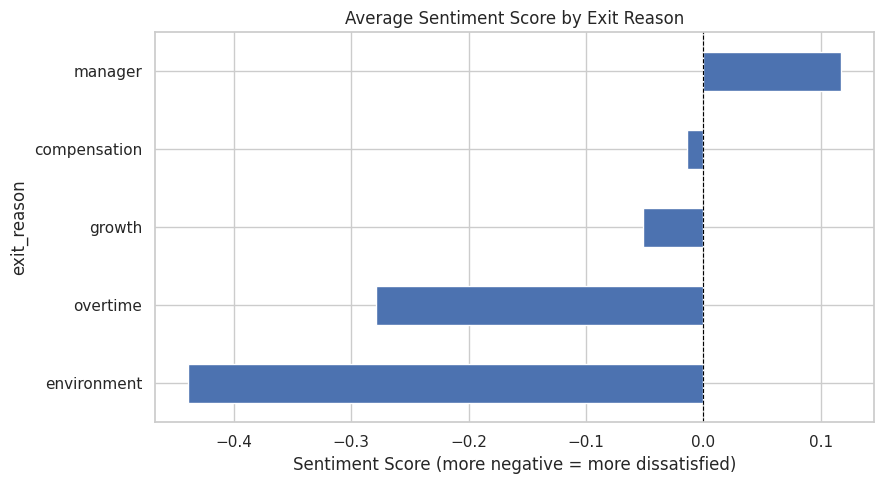

In [46]:
avg_sentiment = left_employees.groupby('exit_reason')['sentiment_score'].mean().sort_values()

plt.figure(figsize=(9, 5))
avg_sentiment.plot(kind='barh', color='#4C72B0', edgecolor='white')
plt.title('Average Sentiment Score by Exit Reason')
plt.xlabel('Sentiment Score (more negative = more dissatisfied)')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Attrition_Project/outputs/plots/sentiment_by_reason.png', dpi=150)
plt.show()

In [47]:
from gensim import corpora
from gensim.models import LdaModel
from gensim.parsing.preprocessing import STOPWORDS
import warnings
warnings.filterwarnings('ignore')

# Tokenize and clean
def preprocess(text):
    return [word.lower() for word in text.split()
            if word.lower() not in STOPWORDS and len(word) > 3]

tokenized = left_employees['exit_comment'].apply(preprocess).tolist()

# Build dictionary and corpus
dictionary = corpora.Dictionary(tokenized)
corpus = [dictionary.doc2bow(doc) for doc in tokenized]

# Train LDA
lda_model = LdaModel(corpus=corpus, id2word=dictionary,
                     num_topics=5, random_state=42,
                     passes=15, alpha='auto')

print("Top words per topic:\n")
for i, topic in lda_model.print_topics(num_words=5):
    print(f"Topic {i+1}: {topic}")

Top words per topic:

Topic 1: 0.174*"better" + 0.072*"despite" + 0.072*"workload" + 0.072*"crushing" + 0.072*"raising"
Topic 2: 0.115*"manager" + 0.047*"workplace" + 0.047*"negative" + 0.047*"demotivating" + 0.047*"culture"
Topic 3: 0.102*"poor" + 0.057*"dynamics" + 0.057*"constant" + 0.057*"conflicts" + 0.057*"internal"
Topic 4: 0.073*"late" + 0.073*"working" + 0.051*"environment" + 0.042*"work-life" + 0.042*"constantly"
Topic 5: 0.099*"career" + 0.052*"growth" + 0.052*"path" + 0.052*"opportunity" + 0.052*"clear"


In [48]:
left_employees[['exit_reason', 'exit_comment', 'sentiment_label', 'sentiment_score']].to_csv(
    '/content/drive/MyDrive/Attrition_Project/data/processed/exit_survey.csv',
    index=False
)

print("Exit survey data saved!")
print("\nFinal shape:", left_employees.shape)

Exit survey data saved!

Final shape: (237, 34)


**Phase 7 — Streamlit Dashboard**

In [49]:
app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# ── Page config ──────────────────────────────────────────────
st.set_page_config(page_title="Employee Attrition Dashboard",
                   layout="wide", page_icon="👥")

st.title("👥 Employee Attrition Risk Dashboard")
st.markdown("Predict attrition risk, understand drivers, and analyze exit sentiment.")

# ── Load assets ───────────────────────────────────────────────
@st.cache_resource
def load_assets():
    model  = joblib.load("models/logistic_regression.pkl")
    scaler = joblib.load("models/scaler.pkl")
    return model, scaler

@st.cache_data
def load_data():
    df    = pd.read_csv("data/raw/hr_attrition.csv")
    exits = pd.read_csv("data/processed/exit_survey.csv")
    return df, exits

model, scaler = load_assets()
df, exits     = load_data()

# ── Sidebar ───────────────────────────────────────────────────
st.sidebar.header("🔧 Filter Employees")
dept = st.sidebar.multiselect("Department",
       options=df["Department"].unique(),
       default=df["Department"].unique())

df_filtered = df[df["Department"].isin(dept)]

# ── Tab layout ────────────────────────────────────────────────
tab1, tab2, tab3 = st.tabs(["📊 Overview", "🔮 Risk Predictor", "💬 Exit Sentiment"])

# ══ Tab 1: Overview ══════════════════════════════════════════
with tab1:
    col1, col2, col3, col4 = st.columns(4)
    attrition_rate = (df_filtered["Attrition"] == "Yes").mean() * 100
    col1.metric("Total Employees",    len(df_filtered))
    col2.metric("Attrition Rate",     f"{attrition_rate:.1f}%")
    col3.metric("Avg Monthly Income", f"${df_filtered['MonthlyIncome'].mean():,.0f}")
    col4.metric("Overtime %",
        f"{(df_filtered['OverTime']=='Yes').mean()*100:.1f}%")

    st.subheader("Attrition Rate by Department")
    dept_att = (df_filtered.groupby("Department")["Attrition"]
                .apply(lambda x: (x=="Yes").mean()*100)
                .reset_index()
                .rename(columns={"Attrition": "Attrition Rate (%)"}))
    st.bar_chart(dept_att.set_index("Department"))

    st.subheader("Monthly Income Distribution by Attrition")
    fig, ax = plt.subplots(figsize=(8, 3))
    for label, grp in df_filtered.groupby("Attrition"):
        ax.hist(grp["MonthlyIncome"], bins=30, alpha=0.6, label=label)
    ax.legend(); ax.set_xlabel("Monthly Income")
    st.pyplot(fig); plt.close()

# ══ Tab 2: Risk Predictor ════════════════════════════════════
with tab2:
    st.subheader("🔮 Predict Attrition Risk for an Employee")
    st.markdown("Adjust the sliders and the model will predict attrition probability.")

    col1, col2, col3 = st.columns(3)
    with col1:
        age         = st.slider("Age",               18, 60, 30)
        monthly_inc = st.slider("Monthly Income",  1000, 20000, 5000)
        overtime    = st.selectbox("Overtime", ["No","Yes"])
    with col2:
        env_sat     = st.slider("Environment Satisfaction", 1, 4, 3)
        job_sat     = st.slider("Job Satisfaction",         1, 4, 3)
        wlb         = st.slider("Work-Life Balance",        1, 4, 3)
    with col3:
        yrs_company = st.slider("Years at Company",     0, 40, 5)
        yrs_manager = st.slider("Years with Manager",   0, 20, 3)
        num_comp    = st.slider("Num Companies Worked", 0, 9,  2)

    # Build a representative feature vector (29 features)
    # Fill unshown features with dataset medians
    median_row = df_filtered.median(numeric_only=True)

    feature_vector = {
        "Age": age, "DailyRate": median_row.get("DailyRate", 800),
        "DistanceFromHome": median_row.get("DistanceFromHome", 7),
        "Education": 3, "EnvironmentSatisfaction": env_sat,
        "HourlyRate": median_row.get("HourlyRate", 66),
        "JobInvolvement": 3, "JobSatisfaction": job_sat,
        "MonthlyIncome": monthly_inc, "MonthlyRate": median_row.get("MonthlyRate", 14000),
        "NumCompaniesWorked": num_comp, "PercentSalaryHike": 13,
        "PerformanceRating": 3, "RelationshipSatisfaction": 3,
        "StockOptionLevel": 1, "TotalWorkingYears": max(age-22, 0),
        "TrainingTimesLastYear": 3, "WorkLifeBalance": wlb,
        "YearsAtCompany": yrs_company, "YearsInCurrentRole": max(yrs_company-2, 0),
        "YearsSinceLastPromotion": 2, "YearsWithCurrManager": yrs_manager,
        "BusinessTravel": 1, "Department": 1, "EducationField": 1,
        "Gender": 1, "JobRole": 1, "MaritalStatus": 1,
        "OverTime": 1 if overtime == "Yes" else 0,
    }

    fv = pd.DataFrame([feature_vector])
    fv_scaled = scaler.transform(fv)
    prob = model.predict_proba(fv_scaled)[0][1]

    color = "🔴" if prob > 0.5 else "🟡" if prob > 0.3 else "🟢"
    st.markdown(f"### {color} Attrition Risk: **{prob:.1%}**")
    st.progress(float(prob))

    if prob > 0.5:
        st.error("High risk — immediate HR intervention recommended")
    elif prob > 0.3:
        st.warning("Moderate risk — consider a retention conversation")
    else:
        st.success("Low risk — employee appears stable")

# ══ Tab 3: Exit Sentiment ════════════════════════════════════
with tab3:
    st.subheader("💬 Exit Survey Sentiment Analysis")

    col1, col2 = st.columns(2)

    with col1:
        st.markdown("**Exit reasons distribution**")
        reason_counts = exits["exit_reason"].value_counts()
        st.bar_chart(reason_counts)

    with col2:
        st.markdown("**Sentiment breakdown**")
        sent_counts = exits["sentiment_label"].value_counts()
        fig, ax = plt.subplots(figsize=(4, 3))
        ax.pie(sent_counts, labels=sent_counts.index,
               autopct="%1.0f%%",
               colors=["#DD8452","#4C72B0","#55A868"])
        st.pyplot(fig); plt.close()

    st.subheader("Sample Exit Comments")
    reason_filter = st.selectbox("Filter by reason", ["All"] + list(exits["exit_reason"].unique()))
    df_exits_show = exits if reason_filter == "All" else exits[exits["exit_reason"] == reason_filter]
    st.dataframe(df_exits_show[["exit_reason","exit_comment","sentiment_label","sentiment_score"]]
                 .sample(min(10, len(df_exits_show)))
                 .reset_index(drop=True), use_container_width=True)

    avg_sent = exits.groupby("exit_reason")["sentiment_score"].mean().sort_values()
    st.subheader("Average Sentiment Score by Exit Reason")
    st.bar_chart(avg_sent)
'''

with open('/content/drive/MyDrive/Attrition_Project/app.py', 'w') as f:
    f.write(app_code)

print("app.py saved!")

app.py saved!


In [50]:
!pip install streamlit pyngrok -q
print("Streamlit installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 63.1 MB/s eta 0:00:00
Streamlit installed!


In [51]:
import subprocess, time, threading

os.chdir('/content/drive/MyDrive/Attrition_Project')

# Start Streamlit
proc = subprocess.Popen(
    ["streamlit", "run", "app.py",
     "--server.port", "8501",
     "--server.headless", "true"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

time.sleep(5)
print("Streamlit started...")

# Start localtunnel
tunnel = subprocess.Popen(
    ["npx", "localtunnel", "--port", "8501"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

time.sleep(5)

# Read the URL
for line in tunnel.stdout:
    decoded = line.decode().strip()
    if "https://" in decoded:
        print("=" * 50)
        print("Your app is live at:")
        print(decoded)
        print("=" * 50)
        print("\nNote: Click the link, then click 'Click to Continue' on the landing page")
        break

Streamlit started...
Your app is live at:
your url is: https://bright-singers-enter.loca.lt

Note: Click the link, then click 'Click to Continue' on the landing page


In [55]:
!pip install pyngrok -q
from pyngrok import ngrok

# Run this when you want to stop
proc.terminate()
ngrok.kill()
print("App stopped.")

App stopped.
